In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------------------------
# 1. Single Gaussian (1D)
# ---------------------------
def sample_single_gaussian_1d(n=1000, mean=0.0, std=0.5, x=None):
    """
    Single Gaussian (1D): a fixed 1D Gaussian that does not depend on x.
    """
    samples = np.random.normal(loc=mean, scale=std, size=n)
    return samples



def sample_uniform_1d(n=1000, low=-1.0, high=1.0, x=None):
    """
    Uniform (1D): a fixed 1D uniform distribution that does not depend on x.

    参数：
        n   - 样本数量
        low - 区间下界
        high- 区间上界
        x   - 保留参数（与高斯版接口一致）
    返回：
        samples: (n,) 的 numpy 数组
    """
    samples = np.random.uniform(low=low, high=high, size=n)
    return samples


# ---------------------------
# 3. Changing Checkerboard (1D)
# ---------------------------
def sample_changing_checkerboard_1d(n=1000, x=0.0):
    """
    Changing Checkerboard (1D):
    A 1D mixture of 4 evenly spaced modes.
    As x increases from 0 → 1, the modes shift by half an interval
    (similar to interpolating between checkerboard and complementary pattern).
    """
    n_cells = 4
    centers = np.linspace(-2, 2, n_cells, endpoint=False) + 0.5
    centers_complement = centers + 0.5
    interp_centers = (1 - x) * centers + x * centers_complement

    idx = np.random.randint(0, len(interp_centers), size=n)
    samples = interp_centers[idx] + 0.1 * np.random.randn(n)
    return samples

def sample_changing_bimodal_1d(n=1000, x=0.0):
    """
    Changing Bimodal (1D):
    Two modes whose centers gradually shift as x increases from 0 → 1.
    """
    # 初始左右两个峰
    mean_left = -2.0
    mean_right = 2.0

    # 随 x 平移，向中间靠拢或移动
    mean_left_interp = mean_left + x  # 左峰右移
    mean_right_interp = mean_right - x  # 右峰左移

    # 随机选择哪个峰
    comp = np.random.choice([0, 1], size=n)
    samples = np.where(comp == 0,
                       np.random.normal(mean_left_interp, 0.5, n),
                       np.random.normal(mean_right_interp, 0.1, n))
    return samples

def sample_changing_trimodal_1d(n=1000, x=0.0):
    """
    Changing Trimodal (1D):
    Three Gaussian modes whose centers gradually shift as x increases from 0 → 1.
    The three peaks can move toward the center or cross each other, depending on x.

    Args:
        n: number of samples
        x: control variable in [0, 1] determining mode positions

    Returns:
        samples: np.ndarray of shape [n]
    """

    # 初始三个峰的位置
    mean_left = -3.0
    mean_mid = 0.0
    mean_right = 3.0

    # 随 x 平滑移动：左右峰向中间靠拢，中间峰轻微偏移（制造动态）
    mean_left_interp = mean_left + 1.5 * x       # 左峰右移
    mean_mid_interp = mean_mid + 0.5 * np.sin(np.pi * x)  # 中间峰轻微摆动
    mean_right_interp = mean_right - 1.5 * x     # 右峰左移

    # 三个分量的权重可随 x 改变（可选）
    weights = np.array([
        0.3 + 0.2 * np.sin(2 * np.pi * x),  # 左峰
        0.4,                                # 中峰
        0.3 - 0.2 * np.sin(2 * np.pi * x)   # 右峰
    ])
    weights = np.clip(weights, 0.05, None)
    weights /= np.sum(weights)  # 归一化

    # 选择每个样本属于哪个峰
    comp = np.random.choice([0, 1, 2], size=n, p=weights)

    # 从对应高斯峰采样
    samples = np.empty(n)
    samples[comp == 0] = np.random.normal(mean_left_interp, 0.25, np.sum(comp == 0))
    samples[comp == 1] = np.random.normal(mean_mid_interp, 0.25, np.sum(comp == 1))
    samples[comp == 2] = np.random.normal(mean_right_interp, 0.25, np.sum(comp == 2))

    return samples


xi = 0.5


x = 0.5
samples = sample_uniform_1d(n=1000, x=x)

# # 核密度估计 (KDE)
# kde = gaussian_kde(samples)
# xs = np.linspace(-4, 4, 400)
# pdf = kde(xs)

# # 绘图
# plt.figure(figsize=(6, 4))
# plt.plot(xs, pdf, color='royalblue', lw=2)
# plt.fill_between(xs, pdf, color='skyblue', alpha=0.4)



# # samples = sample_changing_checkerboard_1d(x=xi)
# # plt.figure(figsize=(6, 4))
# # plt.hist(samples, bins=60, range=(-3, 3), density=True, color='skyblue', edgecolor='black', alpha=0.7)


# plt.xlim(-4,4)
# plt.ylim(-0.,1.5)


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def make_mlp(l_dim, d_model, dim, num_layers=4):
    layers = []
    in_dim = l_dim
    for _ in range(num_layers):
        layers += [
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        ]
        in_dim = d_model
    layers.append(nn.Linear(d_model, dim))
    return nn.Sequential(*layers)

class Model(nn.Module):
    def __init__(self, dim, head):
        super().__init__()

        self.d_model = 256
        self.l_dim = 128
        self.dim = dim
        self.num_head = head

        self.lin1 = nn.Linear(1, self.d_model)
        self.mu = nn.Linear(self.d_model, self.dim)
        self.logvar = nn.Linear(self.d_model, self.dim)

        self.fc1 = nn.Linear(self.dim, self.d_model)
        self.fc2 = nn.Linear(self.d_model, self.dim)


        self.nets = nn.ModuleList([make_mlp(self.dim, self.d_model, dim) for _ in range(self.num_head)])



    def project(self, z):
        # z = F.gelu(self.fc1(z))
        # z = self.fc2(z)


        z_list = []
        for i in range(self.num_head):
            out = self.nets[i](z)
            z_list.append(out)
        z = torch.cat(z_list, dim=-2)
        # z = z1

        return z
    
    def encode(self, x):
        h = F.gelu(self.lin1(x))
        mu = self.mu(h)
        logvar = self.logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar, K):
        std = torch.exp(0.5 * logvar)   # standard deviation

        mu = mu.unsqueeze(-2).expand(-1, K, -1)
        std = std.unsqueeze(-2).expand(-1, K, -1)

        eps = torch.randn_like(std)     # sample epsilon ~ N(0, I)
        return mu + eps * std           # z = mu + std * eps

    def forward(self, x, K):
        mu, logvar = self.encode(x)

        # print(mu[0,:], torch.exp(0.5 * logvar)[0,:])
        # assert 0

        z = self.reparameterize(mu, logvar, K)

        prior = z

        output = self.project(z)

        return output, prior
    

# class MultiModel(nn.Module):
#     def __init__(self, dim):
#         super().__init__()

#         self.d_model = 256
#         self.l_dim = 32
#         self.dim = dim

#         self.lin1 = nn.Linear(1, self.d_model)
#         self.lin2 = nn.Linear(self.d_model, self.d_model)
        
#         self.K = 300
#         self.net = nn.ModuleList(nn.Linear(self.d_model, self.dim) for _ in range(self.K))

#     def forward(self, x, K=0):
#         x = self.lin1(x)
#         x = F.gelu(self.lin2(x))

#         result_list = []
#         for i in range(self.K):
#             result = self.net[i](x)
#             result_list.append(result.unsqueeze(-2))
#         output = torch.cat(result_list, dim=-2)

#         return output

def min_loss(pred, true):
    loss = (pred - true.unsqueeze(1))**2
    loss = torch.sum(loss, dim=-1)
    loss = torch.min(loss, dim=1)[0]

    return loss.mean()

# def min_loss(pred, true):
#     loss = (pred - true.unsqueeze(1))**2
#     # loss = torch.abs(pred - true.unsqueeze(1))
#     loss = torch.sum(loss, dim=-1)
    
#     amcl_weights = torch.softmax(
#                 -loss / 0.01, dim=1   # 0.1
#             ).detach()  # shape [batch_size,K]

#     loss = amcl_weights * loss

#     return loss.mean()

def soft_wta_loss(pred, true, tau=0.01):
    # pred: shape [batch_size, K, dim]
    # true: shape [batch_size, dim]
    
    # Compute squared loss for each component
    loss = (pred - true.unsqueeze(1))**2
    loss = torch.sum(loss, dim=-1)  # shape [batch_size, K]
    
    # Compute log-sum-exp
    lse_loss = -tau * torch.logsumexp(-loss / tau, dim=1)  # shape [batch_size]
    
    return lse_loss.mean()

def mean_loss(pred, true):
    mean_pred = torch.mean(pred, dim=1)
    loss = (mean_pred - true)**2

    return loss.mean()

2.045809755425595
-0.020221438327281453
-0.021724339757299205
-0.022500120865295167


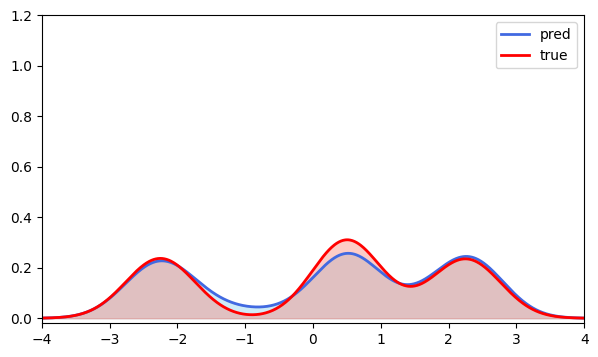

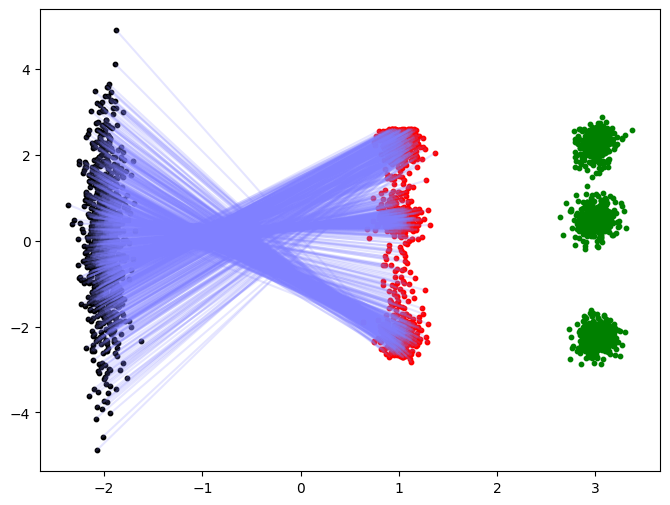

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# data = sample_single_gaussian(x=0.5)   # ← 你自己的数据集或 DataLoader
# data = gaussian_to_two_moons(data)
# data = sample_rotating_two_moons(n=1000, x=0.5)
# data = sample_changing_damier(x=0.5)

# data = sample_single_gaussian_1d(n=1000, x=0.5)
# data = sample_changing_bimodal_1d(x=0.5)
data = sample_changing_trimodal_1d(x=0.5)
# data = sample_uniform_1d(n=2000, x=0.5, low=-1.0, high=1.0)
data = np.expand_dims(data, axis=-1)

dim=1


model = Model(dim, 1)  # ← 你自己的神经网络
# model = MultiModel(1)
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 200
device = "cuda" if torch.cuda.is_available() else "cpu"

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    
    true_data = torch.tensor(data).to(device)
    # .unsqueeze(-1)

    x = torch.full((len(true_data),1), 0.5).to(device)

    # --- 前向传播 ---
    outputs, _ = model(x, 200)
    # print(outputs.shape, true_data.shape)
    # assert 0
    # loss = min_loss(outputs, true_data) + mean_loss(outputs, true_data)
    loss = soft_wta_loss(outputs, true_data) 
    # + mean_loss(outputs, true_data)
    # loss = mean_loss(outputs, true_data)

    # --- 反向传播与更新 ---
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    
    if epoch % 50 == 0:
        print(loss.item())

    # avg_loss = total_loss / len(data)
    # print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {total_loss:.4f}")

# assert 0
model.eval()
with torch.no_grad():
    x = torch.full((1,1), 0.5).to(device)
    pred_data, prior = model(x, 1000)
    pred_data, prior = pred_data[0], prior[0]
    # print(pred_data.shape)

    samples = pred_data.detach().cpu().numpy()
    prior = prior.detach().cpu().numpy()


    # plt.figure()
    # plt.scatter(data[:,0], data[:,1], s=8, alpha=0.6)
    # plt.scatter(samples[:,0], samples[:,1], s=8, alpha=0.8, color='red')
    # plt.title(f"Single Gaussian (x={xi:.2f})")
    # plt.axis('equal')
    # plt.xlim(-2,2)
    # plt.ylim(-2,2)

    plt.figure(figsize=(7, 4))
    xs = np.linspace(-4, 4, 1000)
    # data = sample_single_gaussian_1d(n=1000, x=0.5)

    kde_pred = gaussian_kde(samples[:,0])
    pdf_pred = kde_pred(xs)
    kde_true = gaussian_kde(data[:,0])
    pdf_true = kde_true(xs)
    plt.plot(xs, pdf_pred, color='royalblue', lw=2, label='pred')
    plt.fill_between(xs, pdf_pred, color='skyblue', alpha=0.4)
    plt.plot(xs, pdf_true, color='red', lw=2, label='true')
    plt.fill_between(xs, pdf_true, color='salmon', alpha=0.4)

    plt.legend()
    plt.xlim(-4,4)
    plt.ylim(-0.02, 1.2)
    #     # 可以保存或可视化 preds

    plt.figure(figsize=(8,6))
    x_1 = samples[:,0]
    x_0 = prior[:,0]

    # print(x_1.shape)

    noise = np.random.normal(loc=0, scale=0.1, size=len(x_1))

    x_0 = np.stack((noise-2, x_0),axis=1)
    x_1 = np.stack((noise+1, x_1),axis=1)

    # noise = np.random.normal(loc=0, scale=0.1, size=len(data))
    data_x = np.stack((noise+3, data[:,0]),axis=1)

    for i in range(len(x_0)):
        plt.plot([x_0[i, 0], x_1[i, 0]], [x_0[i, 1], x_1[i, 1]], color=(0.5, 0.5, 1, 0.2))  # 半透明连线

    # # 绘制两侧分布
    plt.scatter(x_0[:, 0], x_0[:, 1], color='black', s=10, label='x (source)')
    plt.scatter(x_1[:, 0], x_1[:, 1], color='red', s=10, label='y = f(x) (target)')
    plt.scatter(data_x[:, 0], data_x[:, 1], color='green', s=10, label='data')



Epoch 0: Loss = 0.3150
Epoch 10: Loss = 0.2078
Epoch 20: Loss = 0.2663
Epoch 30: Loss = 0.1816
Epoch 40: Loss = 0.1660
Epoch 50: Loss = 0.2374
Epoch 60: Loss = 0.2077
Epoch 70: Loss = 0.2611
Epoch 80: Loss = 0.2234
Epoch 90: Loss = 0.2289
Epoch 100: Loss = 0.2367
Epoch 110: Loss = 0.1834
Epoch 120: Loss = 0.1948
Epoch 130: Loss = 0.2488
Epoch 140: Loss = 0.1442
Epoch 150: Loss = 0.1714
Epoch 160: Loss = 0.1557
Epoch 170: Loss = 0.2167
Epoch 180: Loss = 0.2285
Epoch 190: Loss = 0.2273


(-0.02, 1.2)

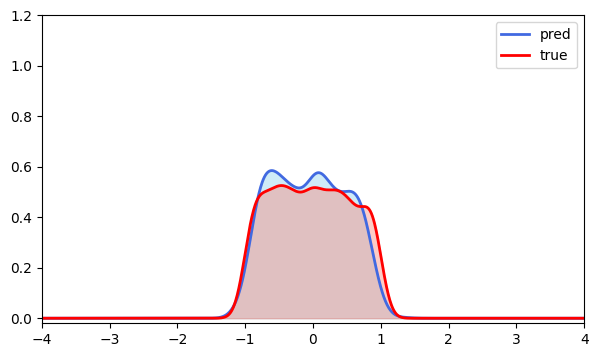

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# --------------------------
# 1. 简单的三层 MLP 去噪网络
# --------------------------
class SimpleDenoiseMLP(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim+1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, dim)
        )
        # self.d_model = 128
        # self.net = nn.Sequential(
        #             nn.Linear(dim+1, self.d_model),
        #             nn.LayerNorm(self.d_model),
        #             nn.GELU(),

        #             nn.Linear(self.d_model, self.d_model),
        #             nn.LayerNorm(self.d_model),
        #             nn.GELU(),

        #             nn.Linear(self.d_model, self.d_model),
        #             nn.LayerNorm(self.d_model),
        #             nn.GELU(),

        #             nn.Linear(self.d_model, self.d_model),
        #             nn.LayerNorm(self.d_model),
        #             nn.GELU(),

        #             nn.Linear(self.d_model, dim)
        #         )
    def forward(self, x, t):
        # 简单方式将时间步 t 作为输入特征的一部分
        t_embed = t.unsqueeze(-1).float() / 1000  # normalize
        x_in = torch.cat([x, t_embed], dim=-1)
        return self.net(x_in)
device = "cuda" if torch.cuda.is_available() else "cpu"
# --------------------------
# 2. 定义简单扩散过程参数
# --------------------------
T = 1000  # 扩散步数
beta = torch.linspace(1e-4, 0.02, T)  # noise schedule
alpha = 1 - beta
alpha = alpha.to(device)
alpha_bar = torch.cumprod(alpha, dim=0).to(device)

# --------------------------
# 3. 前向扩散过程 q(x_t | x_0)
# --------------------------
def q_sample(x0, t):
    noise = torch.randn_like(x0)
    a_bar = alpha_bar[t].view(-1, 1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise
    return xt, noise

# --------------------------
# 4. 训练循环
# --------------------------
def train(data, d):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dim = d  # 输入维度
    model = SimpleDenoiseMLP(dim).to(device)  # +1 for time embedding
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # 简单 synthetic dataset
    # data = torch.randn(1000, dim).to(device)
    
    
    data = torch.tensor(data).to(device)
    epochs = 200
    batch_size = 256

    for epoch in range(epochs):
        perm = torch.randperm(len(data))
        for i in range(0, len(data), batch_size):
            x0 = data[perm[i:i+batch_size]]
            t = torch.randint(0, T, (x0.size(0),), device=device)


            xt, noise = q_sample(x0, t)

            xt = xt.float()
            noise = noise.float()

            pred_noise = model(xt, t)
            loss = nn.MSELoss()(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

    return model

# --------------------------
# 5. 推理/采样
# --------------------------
@torch.no_grad()
def sample(model, n_samples=5, dim=10):
    device = next(model.parameters()).device
    x = torch.randn(n_samples, dim).float().to(device)  # 从标准高斯初始化
    # x = torch.zeros_like(x)
    # x = torch.abs(x)
    for t in reversed(range(T)):
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)
        # print(x.shape, t_tensor.shape)
        pred_noise = model(x, t_tensor)
        a = alpha[t]
        a_bar = alpha_bar[t]
        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0

        # return (1 / torch.sqrt(a)) * (x - (1 - a) / torch.sqrt(1 - a_bar) * pred_noise)
        x = (1 / torch.sqrt(a)) * (x - (1 - a) / torch.sqrt(1 - a_bar) * pred_noise) + torch.sqrt(beta[t]) * noise     
        # return x    
    return x


data = sample_single_gaussian_1d(n=1000, x=0.5)
data = sample_changing_bimodal_1d(x=0.5)
# data = sample_changing_trimodal_1d(x=0.5)
data = sample_uniform_1d(n=2000, x=0.5, low=-1.0, high=1.0)
data = np.expand_dims(data, axis=-1)

# data = sample_rotating_two_moons(n=1000, x=0.5)
# data = sample_changing_damier(x=0.5)

dim=1

model = train(data, d=dim)
device = "cuda" if torch.cuda.is_available() else "cpu"
# model = SimpleDenoiseMLP(1).to(device)  # 输入维度 + time embedding
samples = sample(model, n_samples=1000, dim=dim)
# print(samples[:10])


# plt.figure()
# plt.scatter(data[:,0], data[:,1], s=8, alpha=0.6)
# samples = samples.detach().cpu().numpy()
# plt.scatter(samples[:,0], samples[:,1], s=8, alpha=0.8, color='red')
# plt.title(f"Single Gaussian (x={xi:.2f})")
# plt.axis('equal')
# plt.xlim(-2,2)
# plt.ylim(-2,2)


plt.figure(figsize=(7, 4))
xs = np.linspace(-4, 4, 1000)
# data = sample_single_gaussian_1d(n=1000, x=0.5)
samples = samples.detach().cpu().numpy()
kde_pred = gaussian_kde(samples[:,0])
pdf_pred = kde_pred(xs)
kde_true = gaussian_kde(data[:,0])
pdf_true = kde_true(xs)
plt.plot(xs, pdf_pred, color='royalblue', lw=2, label='pred')
plt.fill_between(xs, pdf_pred, color='skyblue', alpha=0.4)
plt.plot(xs, pdf_true, color='red', lw=2, label='true')
plt.fill_between(xs, pdf_true, color='salmon', alpha=0.4)

plt.legend()


plt.xlim(-4,4)
plt.ylim(-0.02, 1.2)